In [ ]:
import torch
import matplotlib.pyplot as plt

from src.distributions.stars.ellipsoid.spd_2d_gaussian import SPDEllipsoidGaussianDistribution
from src.distributions.stars.ellipsoid.multi_spd_2d_gaussian import MultiSPDEllipsoidGaussianDistribution    

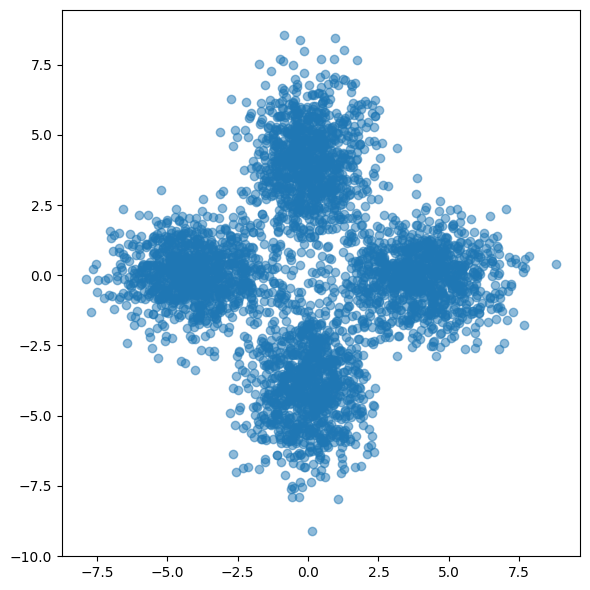

In [2]:
p = 4
q = 2

mean_1 = torch.tensor([p, 0.0])
Sigma_1 = torch.tensor([[q, 0.0], [0., 1.0]])
mean_2 = torch.tensor([0.0, p])
Sigma_2 = torch.tensor([[1.0, 0.0], [0., q]])
mean_3 = torch.tensor([-p, 0.0])
Sigma_3 = torch.tensor([[q, 0.0], [0., 1.0]])
mean_4 = torch.tensor([0.0, -p])
Sigma_4 = torch.tensor([[1.0, 0.0], [0., q]])

# generate data set
n_samples = 1000
data_1 = torch.distributions.MultivariateNormal(mean_1, Sigma_1).sample((n_samples,))
data_2 = torch.distributions.MultivariateNormal(mean_2, Sigma_2).sample((n_samples,))
data_3 = torch.distributions.MultivariateNormal(mean_3, Sigma_3).sample((n_samples,))
data_4 = torch.distributions.MultivariateNormal(mean_4, Sigma_4).sample((n_samples,))
data = torch.cat([data_1, data_2, data_3, data_4], dim=0)

plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
cov_1 = Sigma_1 + mean_1.unsqueeze(1) @ mean_1.unsqueeze(0)
cov_2 = Sigma_2 + mean_2.unsqueeze(1) @ mean_2.unsqueeze(0)
cov_3 = Sigma_3 + mean_3.unsqueeze(1) @ mean_3.unsqueeze(0)
cov_4 = Sigma_4 + mean_4.unsqueeze(1) @ mean_4.unsqueeze(0)

ellipsoid_gaussian_1 = SPDEllipsoidGaussianDistribution(Sigma=cov_1)
ellipsoid_gaussian_2 = SPDEllipsoidGaussianDistribution(Sigma=cov_2)
ellipsoid_gaussian_3 = SPDEllipsoidGaussianDistribution(Sigma=cov_3, sign=-1)
ellipsoid_gaussian_4 = SPDEllipsoidGaussianDistribution(Sigma=cov_4, sign=-1)

print("For Sigma_1: a = {:.2f}, eps = {:.2f}, q = {}".format(ellipsoid_gaussian_1.radial.a, ellipsoid_gaussian_1.radial.eps, ellipsoid_gaussian_1.radial.q))
print("For Sigma_2: a = {:.2f}, eps = {:.2f}, q = {}".format(ellipsoid_gaussian_2.radial.a, ellipsoid_gaussian_2.radial.eps, ellipsoid_gaussian_2.radial.q))
print("For Sigma_3: a = {:.2f}, eps = {:.2f}, q = {}".format(ellipsoid_gaussian_3.radial.a, ellipsoid_gaussian_3.radial.eps, ellipsoid_gaussian_3.radial.q))
print("For Sigma_4: a = {:.2f}, eps = {:.2f}, q = {}".format(ellipsoid_gaussian_4.radial.a, ellipsoid_gaussian_4.radial.eps, ellipsoid_gaussian_4.radial.q))

For Sigma_1: a = 4.24, eps = 0.97, q = tensor([1., 0.])
For Sigma_2: a = 4.24, eps = 0.97, q = tensor([0., 1.])
For Sigma_3: a = 4.24, eps = 0.97, q = tensor([-1., -0.])
For Sigma_4: a = 4.24, eps = 0.97, q = tensor([-0., -1.])


/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


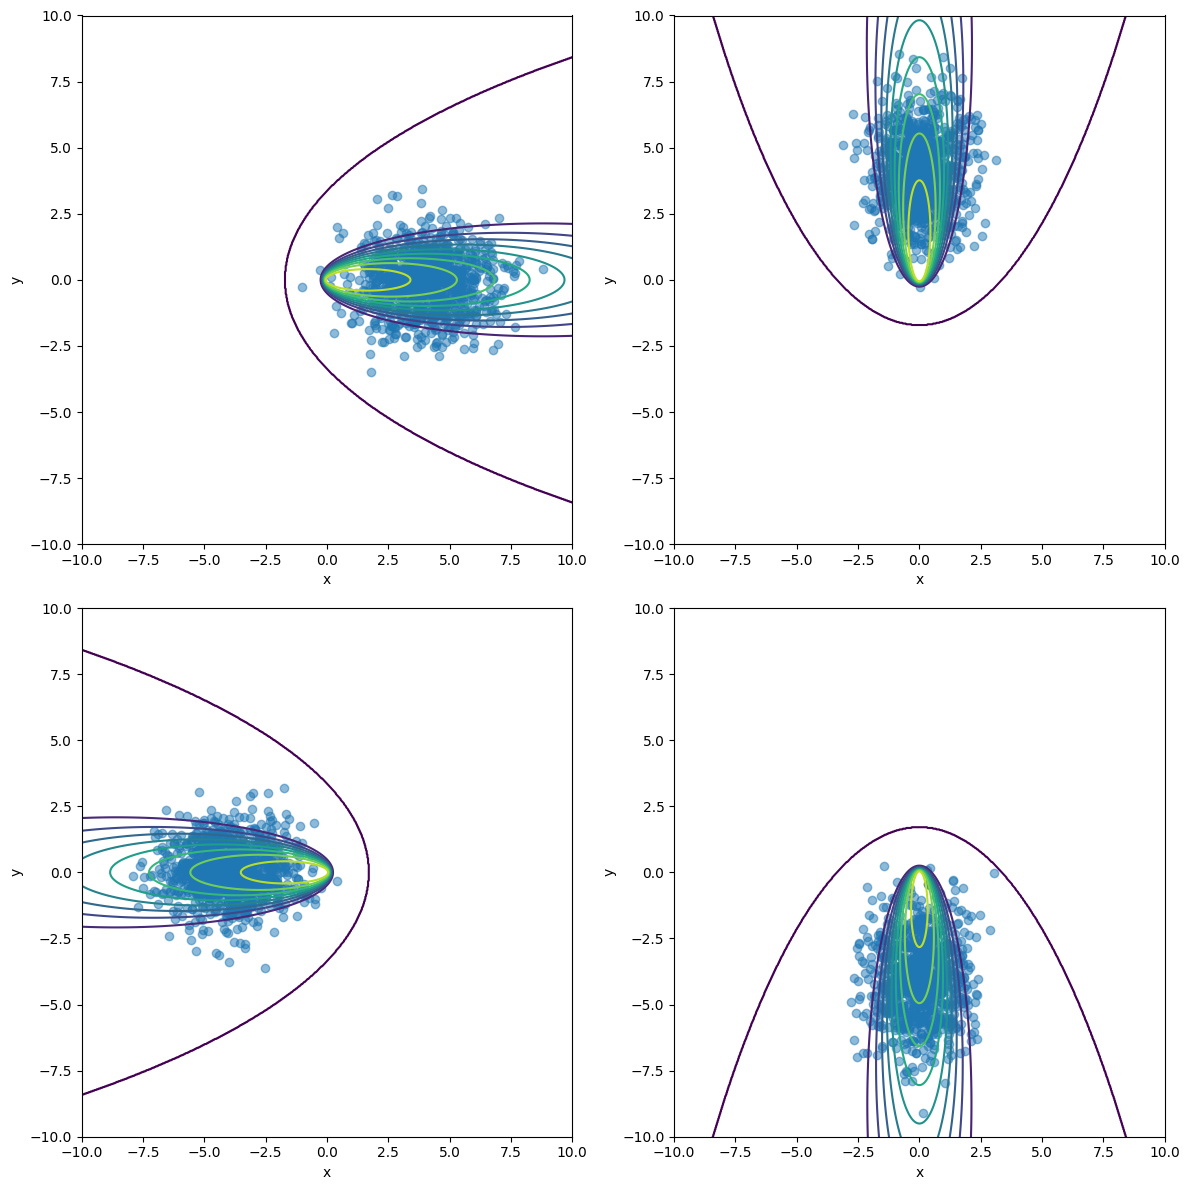

In [4]:
# plot density
n_points = 1001
x = torch.linspace(-14, 14, n_points)
y = torch.linspace(-14, 14, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs_1 = torch.exp(ellipsoid_gaussian_1.log_prob(XY).reshape(n_points, n_points).detach())
log_probs_2 = torch.exp(ellipsoid_gaussian_2.log_prob(XY).reshape(n_points, n_points).detach())
log_probs_3 = torch.exp(ellipsoid_gaussian_3.log_prob(XY).reshape(n_points, n_points).detach())
log_probs_4 = torch.exp(ellipsoid_gaussian_4.log_prob(XY).reshape(n_points, n_points).detach())

plt.figure(figsize=(12,12))
plt.subplot(2, 2, 1)
plt.scatter(data_1[:, 0].numpy(), data_1[:, 1].numpy(), alpha=0.5)
plt.contour(X.numpy(), Y.numpy(), log_probs_1.numpy(), levels=10, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.subplot(2, 2, 2)
plt.scatter(data_2[:, 0].numpy(), data_2[:, 1].numpy(), alpha=0.5)
plt.contour(X.numpy(), Y.numpy(), log_probs_2.numpy(), levels=10, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.tight_layout()
plt.subplot(2, 2, 3)
plt.scatter(data_3[:, 0].numpy(), data_3[:, 1].numpy(), alpha=0.5)
plt.contour(X.numpy(), Y.numpy(), log_probs_3.numpy(), levels=10, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.subplot(2, 2, 4)
plt.scatter(data_4[:, 0].numpy(), data_4[:, 1].numpy(), alpha=0.5)
plt.contour(X.numpy(), Y.numpy(), log_probs_4.numpy(), levels=10, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.tight_layout()
plt.show()

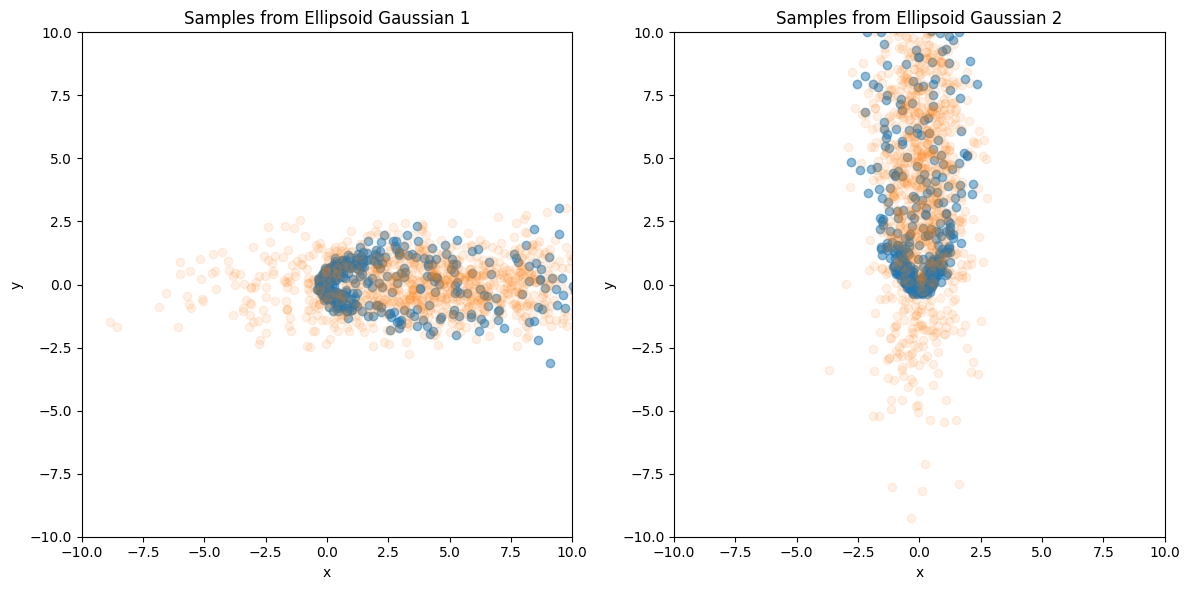

In [5]:
# sample from distributions
samples_1 = ellipsoid_gaussian_1.sample(1000)
samples_2 = ellipsoid_gaussian_2.sample(1000)

gaussian_samples_1 = torch.randn(1000, 2) @ ellipsoid_gaussian_1.radial.Sigma_sqrt + ellipsoid_gaussian_1.radial.a * ellipsoid_gaussian_1.radial.q
gaussian_samples_2 = torch.randn(1000, 2) @ ellipsoid_gaussian_2.radial.Sigma_sqrt + ellipsoid_gaussian_2.radial.a * ellipsoid_gaussian_2.radial.q

# plot samples
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.scatter(samples_1[:, 0].numpy(), samples_1[:, 1].numpy(), alpha=0.5)
plt.scatter(gaussian_samples_1[:, 0].numpy(), gaussian_samples_1[:, 1].numpy(), alpha=0.1, label='Gaussian Samples')
plt.title('Samples from Ellipsoid Gaussian 1')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.subplot(1, 2, 2)
plt.scatter(samples_2[:, 0].numpy(), samples_2[:, 1].numpy(), alpha=0.5)
plt.scatter(gaussian_samples_2[:, 0].numpy(), gaussian_samples_2[:, 1].numpy(), alpha=0.1, label='Gaussian Samples')
plt.title('Samples from Ellipsoid Gaussian 2')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.tight_layout()
plt.show()

In [6]:
multi_ellipsoid_gaussian = MultiSPDEllipsoidGaussianDistribution(2, Sigmas=[Sigma_1, Sigma_2, Sigma_1, Sigma_2], signs=[1, 1, -1, -1], aggregation='max')

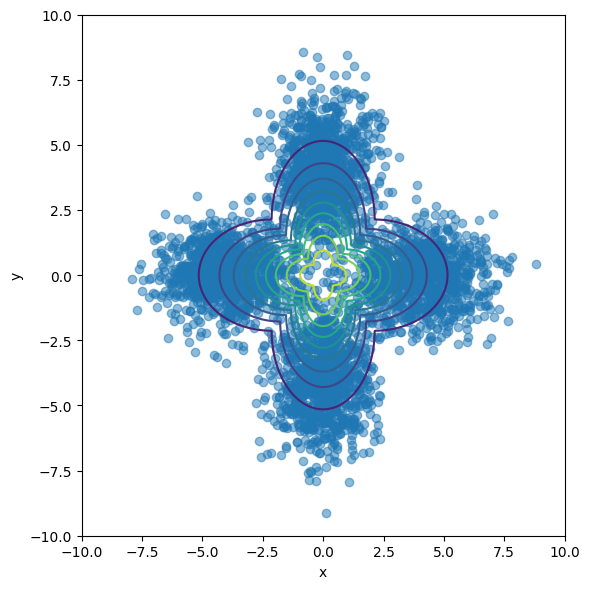

In [7]:
# plot density
n_points = 1001
x = torch.linspace(-14, 14, n_points)
y = torch.linspace(-14, 14, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs_multi = torch.exp(multi_ellipsoid_gaussian.log_prob(XY).reshape(n_points, n_points).detach())

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis')
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.tight_layout()
plt.show()

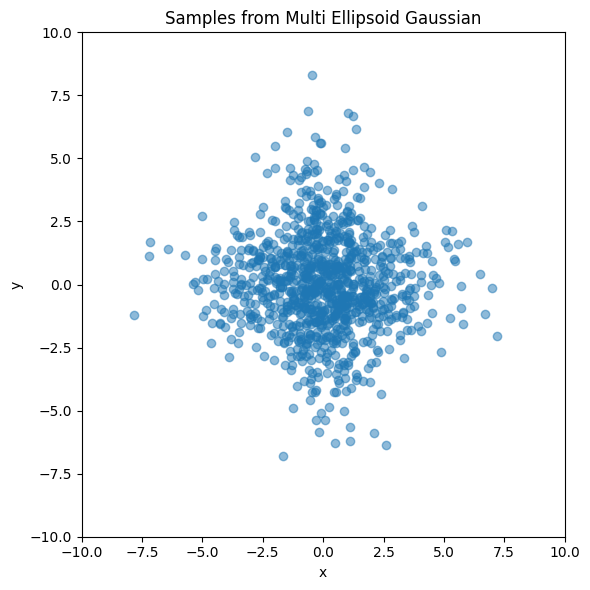

In [8]:
# sample from multi distribution
samples_multi = multi_ellipsoid_gaussian.sample(1000)

# plot samples
plt.figure(figsize=(6,6))
plt.scatter(samples_multi[:, 0].numpy(), samples_multi[:, 1].numpy(), alpha=0.5)
plt.title('Samples from Multi Ellipsoid Gaussian')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.tight_layout()
plt.show()